In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

plt.style.use("ggplot")

In [2]:
emp = pd.read_csv("archive/occupazione.csv")
unemp = pd.read_csv("archive/disoccupazione.csv")

# clean columns
emp.columns = emp.columns.str.strip()
unemp.columns = unemp.columns.str.strip()

emp.head(), unemp.head()

(  iso_code      country    sex    age  year  obs_value
 0      AFG  Afghanistan  Total    15+  2025     32.457
 1      AFG  Afghanistan  Total  15-24  2025     31.419
 2      AFG  Afghanistan  Total    25+  2025     33.056
 3      AFG  Afghanistan   Male    15+  2025     61.038
 4      AFG  Afghanistan   Male  15-24  2025     57.355,
   iso_code      country    sex    age  year  obs_value
 0      AFG  Afghanistan  Total    15+  2025     13.351
 1      AFG  Afghanistan  Total  15-24  2025     16.785
 2      AFG  Afghanistan  Total    25+  2025     11.340
 3      AFG  Afghanistan   Male    15+  2025     12.503
 4      AFG  Afghanistan   Male  15-24  2025     15.814)

In [4]:
emp = emp.rename(columns={"obs_value": "Employment"})
unemp = unemp.rename(columns={"obs_value": "Unemployment"})

In [5]:
# use only total population (clean analysis)
emp = emp[(emp["sex"] == "Total") & (emp["age"] == "15+")]
unemp = unemp[(unemp["sex"] == "Total") & (unemp["age"] == "15+")]

In [6]:
df = pd.merge(
    emp[["iso_code", "country", "year", "Employment"]],
    unemp[["iso_code", "country", "year", "Unemployment"]],
    on=["iso_code", "country", "year"],
    how="inner"
)

df.head()

,iso_code,country,year,Employment,Unemployment
0,AFG,Afghanistan,2025,32.457,13.351
1,AFG,Afghanistan,2024,32.408,13.687
2,AFG,Afghanistan,2023,32.323,14.008
3,AFG,Afghanistan,2022,32.333,14.100
4,AFG,Afghanistan,2021,35.800,12.006


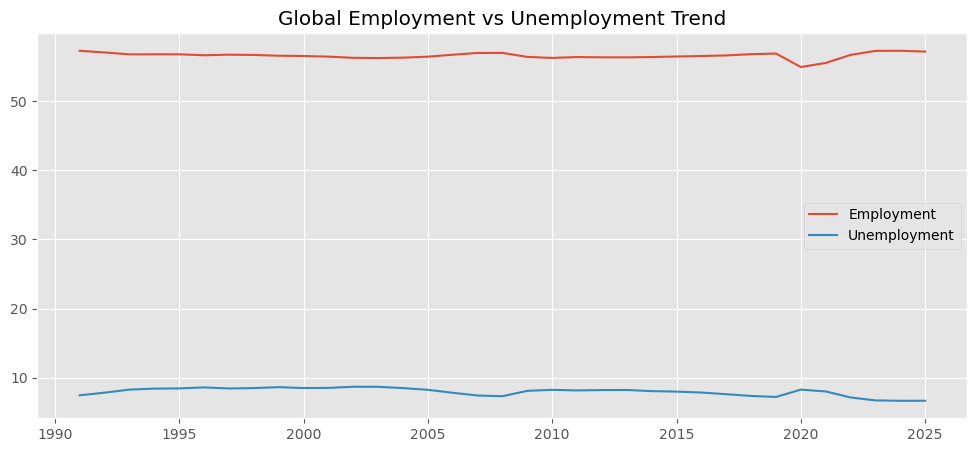

In [7]:
global_trend = df.groupby("year")[["Employment", "Unemployment"]].mean()

plt.figure(figsize=(12,5))

plt.plot(global_trend.index, global_trend["Employment"], label="Employment")
plt.plot(global_trend.index, global_trend["Unemployment"], label="Unemployment")

plt.legend()
plt.title("Global Employment vs Unemployment Trend")

plt.show()

In [8]:
latest_year = df["year"].max()

latest = df[df["year"] == latest_year]

top_unemp = latest.sort_values("Unemployment", ascending=False).head(10)

top_unemp[["country", "Unemployment"]]

,country,Unemployment
5415,Eswatini,34.202
6286,South Africa,32.391
1505,Djibouti,26.015
875,Botswana,24.477
1995,Gabon,20.154
1190,Congo,19.876
4093,Namibia,19.291
5137,Somalia,18.948
3253,Libya,18.758
6076,Saint Vincent and the Grenadines,18.003


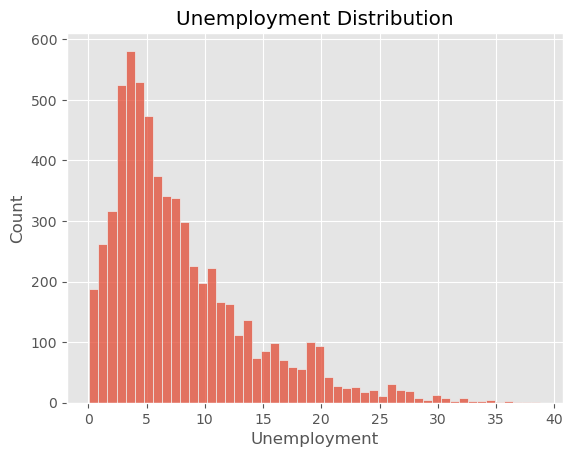

In [9]:
sns.histplot(df["Unemployment"], bins=50)

plt.title("Unemployment Distribution")

plt.show()

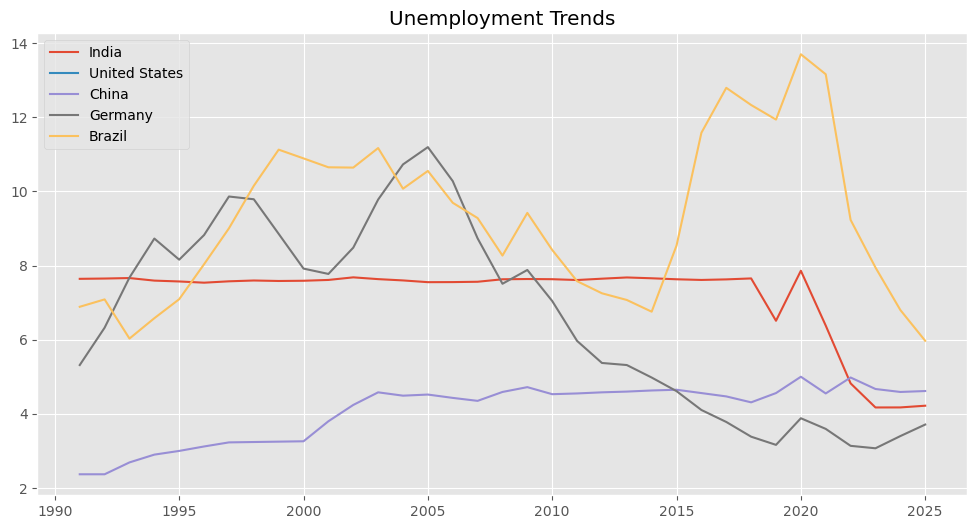

In [10]:
countries = ["India", "United States", "China", "Germany", "Brazil"]

plt.figure(figsize=(12,6))

for c in countries:
    temp = df[df["country"] == c]
    plt.plot(temp["year"], temp["Unemployment"], label=c)

plt.legend()
plt.title("Unemployment Trends")

plt.show()

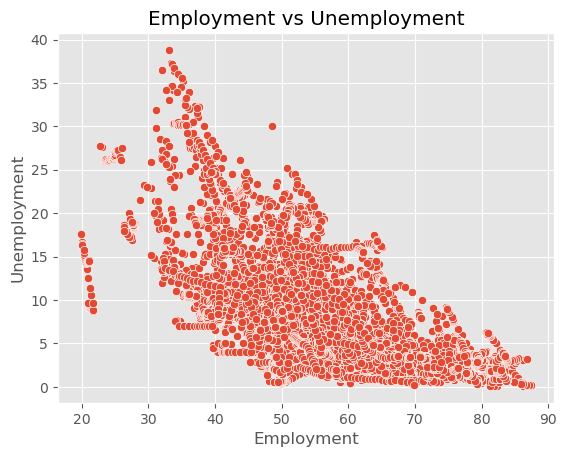

In [11]:
sns.scatterplot(x=df["Employment"], y=df["Unemployment"])

plt.title("Employment vs Unemployment")

plt.show()

In [12]:
df["Unemp_Growth"] = df.groupby("country")["Unemployment"].pct_change() * 100

In [13]:
worst = df.groupby("country")["Unemployment"].mean().sort_values(ascending=False).head(10)

worst

country
North Macedonia                     27.978086
Djibouti                            26.519429
Eswatini                            26.412657
South Africa                        25.242571
Montenegro                          22.931771
Bosnia and Herzegovina              22.431371
Namibia                             20.801743
Congo                               20.079714
Botswana                            19.688343
Saint Vincent and the Grenadines    19.622886
Name: Unemployment, dtype: float64

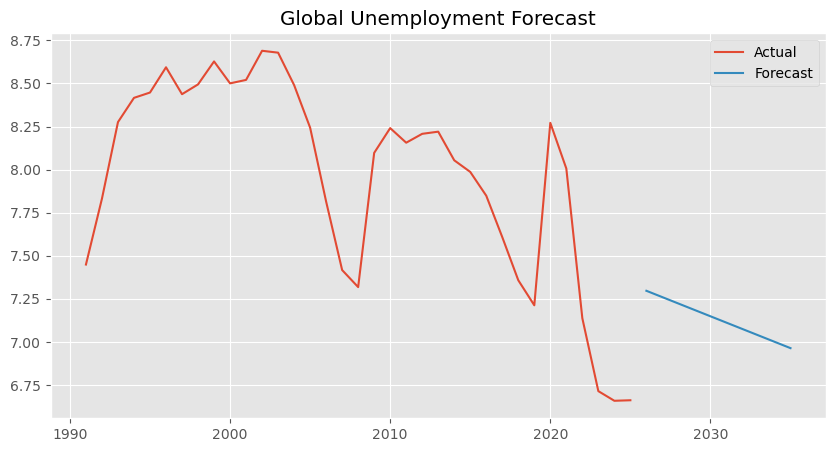

In [14]:
g = global_trend.reset_index()

g["time"] = np.arange(len(g))

model = LinearRegression()
model.fit(g[["time"]], g["Unemployment"])

future = pd.DataFrame({
    "time": np.arange(len(g), len(g)+10)
})

pred = model.predict(future)

future_years = np.arange(g["year"].iloc[-1]+1, g["year"].iloc[-1]+11)

plt.figure(figsize=(10,5))

plt.plot(g["year"], g["Unemployment"], label="Actual")
plt.plot(future_years, pred, label="Forecast")

plt.legend()
plt.title("Global Unemployment Forecast")

plt.show()

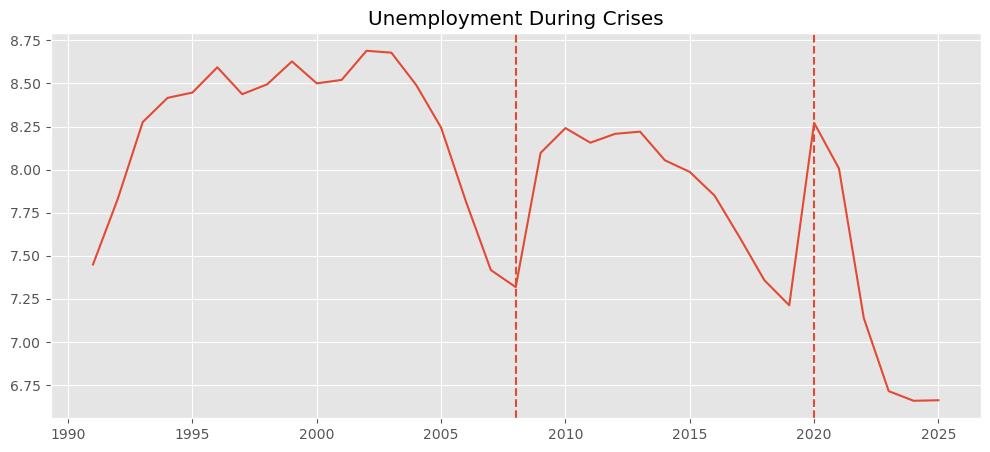

In [15]:
plt.figure(figsize=(12,5))

plt.plot(global_trend.index, global_trend["Unemployment"])

plt.axvline(2008, linestyle="--")
plt.axvline(2020, linestyle="--")

plt.title("Unemployment During Crises")

plt.show()

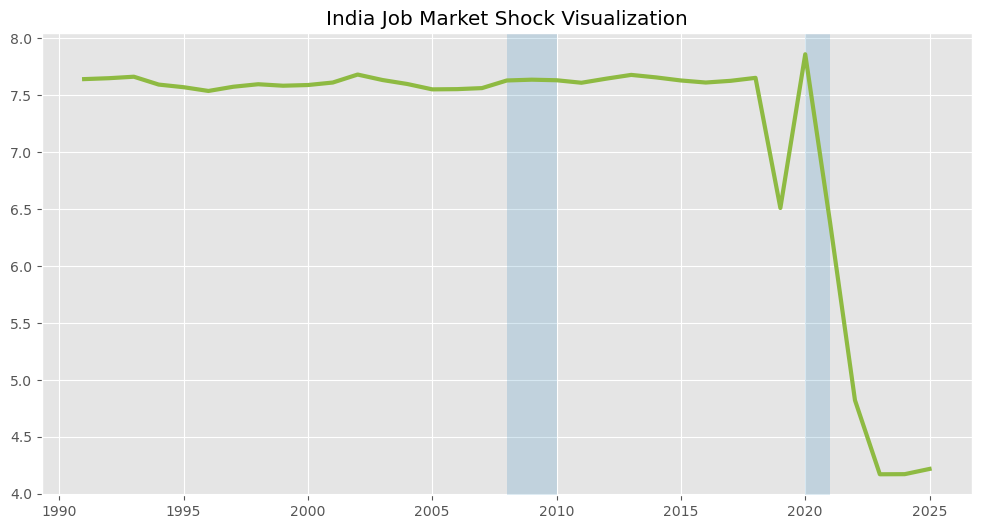

In [18]:
plt.figure(figsize=(12,6))

# glow effect
for i in range(1,6):
    plt.plot(india["year"], india["Unemployment"], alpha=0.1)

plt.plot(india["year"], india["Unemployment"], linewidth=3)

plt.axvspan(2008, 2010, alpha=0.2)
plt.axvspan(2020, 2021, alpha=0.2)

plt.title("India Job Market Shock Visualization")

plt.show()

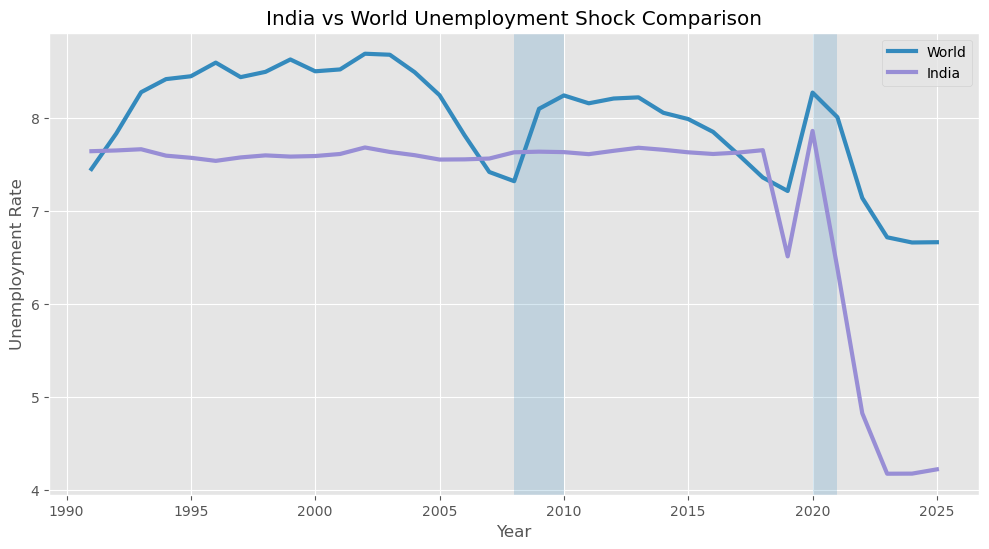

In [19]:
# global average
global_avg = df.groupby("year")["Unemployment"].mean().reset_index()

# india
india = df[df["country"] == "India"]

plt.figure(figsize=(12,6))

# glow effect for both
for i in range(1,5):
    plt.plot(global_avg["year"], global_avg["Unemployment"], alpha=0.1)
    plt.plot(india["year"], india["Unemployment"], alpha=0.1)

# main lines
plt.plot(global_avg["year"], global_avg["Unemployment"], label="World", linewidth=3)
plt.plot(india["year"], india["Unemployment"], label="India", linewidth=3)

# crisis highlight
plt.axvspan(2008, 2010, alpha=0.2)
plt.axvspan(2020, 2021, alpha=0.2)

plt.title("India vs World Unemployment Shock Comparison")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate")

plt.legend()
plt.show()

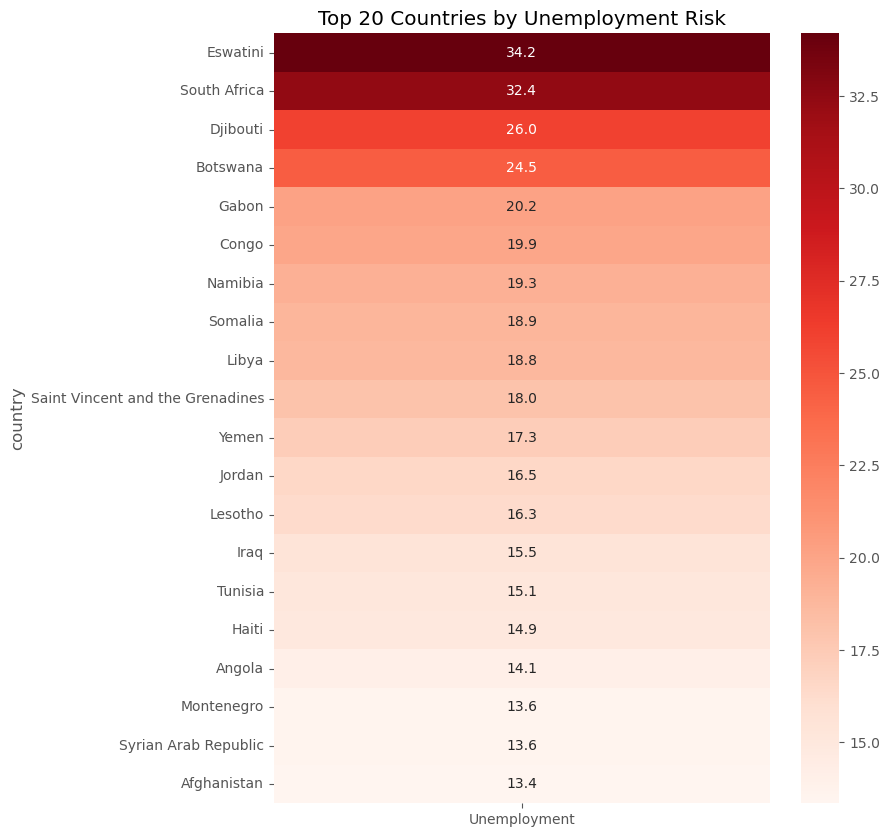

In [20]:
# latest year
latest_year = df["year"].max()
latest = df[df["year"] == latest_year]

# pivot
heatmap_data = latest.pivot_table(
    index="country",
    values="Unemployment"
).sort_values("Unemployment", ascending=False).head(20)

plt.figure(figsize=(8,10))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)

plt.title("Top 20 Countries by Unemployment Risk")

plt.show()

In [21]:
rank = latest.sort_values("Unemployment", ascending=False)

india_rank = rank[rank["country"] == "India"]

india_rank[["country", "Unemployment"]]

,country,Unemployment
2590,India,4.219


In [22]:
recovery_results = []

for country in df["country"].unique():
    
    temp = df[df["country"] == country].sort_values("year").copy()
    
    # skip small data
    if len(temp) < 10:
        continue
    
    # pre-crisis baseline (2005–2007)
    baseline = temp[(temp["year"] >= 2005) & (temp["year"] <= 2007)]["Unemployment"].mean()
    
    # crisis peak (2008–2010)
    crisis = temp[(temp["year"] >= 2008) & (temp["year"] <= 2010)]
    
    if crisis.empty:
        continue
    
    peak = crisis["Unemployment"].max()
    
    # post-crisis recovery (2011 onwards)
    post = temp[temp["year"] >= 2011]
    
    recovery_year = None
    
    for _, row in post.iterrows():
        if row["Unemployment"] <= baseline:
            recovery_year = row["year"]
            break
    
    if recovery_year:
        recovery_time = recovery_year - 2008
    else:
        recovery_time = np.nan
    
    recovery_results.append([country, peak, baseline, recovery_time])

recovery_df = pd.DataFrame(
    recovery_results,
    columns=["Country", "Peak_Unemployment", "Baseline", "Recovery_Years"]
)

recovery_df.head()

,Country,Peak_Unemployment,Baseline,Recovery_Years
0,Afghanistan,7.879,7.872000,3.0
1,Angola,16.595,16.161333,13.0
2,Albania,14.086,15.852667,3.0
3,United Arab Emirates,2.932,3.006000,3.0
4,Argentina,8.645,10.018000,3.0


In [23]:
# fastest recovery
fast = recovery_df.sort_values("Recovery_Years").head(10)

# slowest recovery
slow = recovery_df.sort_values("Recovery_Years", ascending=False).head(10)

fast, slow

(                 Country  Peak_Unemployment   Baseline  Recovery_Years
 0            Afghanistan              7.879   7.872000             3.0
 2                Albania             14.086  15.852667             3.0
 3   United Arab Emirates              2.932   3.006000             3.0
 4              Argentina              8.645  10.018000             3.0
 8             Azerbaijan              5.860   6.736667             3.0
 7                Austria              5.371   5.303667             3.0
 10               Belgium              8.293   8.048333             3.0
 9                Burundi              1.634   2.917000             3.0
 19                Belize              8.412   9.603333             3.0
 18               Belarus              6.728   8.078333             3.0,
                 Country  Peak_Unemployment   Baseline  Recovery_Years
 65               Greece             12.719   9.110333            17.0
 142             Senegal              2.816   2.744667           

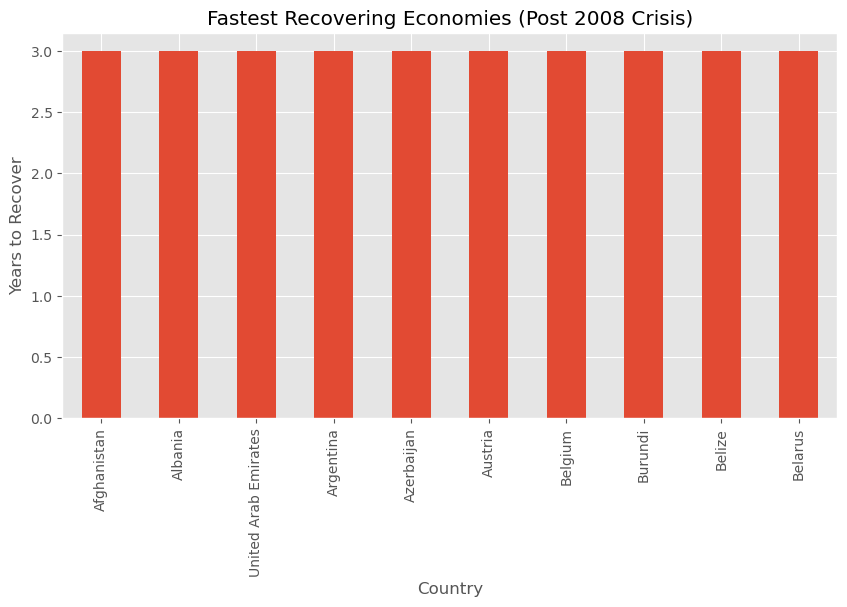

In [24]:
plt.figure(figsize=(10,5))

fast.set_index("Country")["Recovery_Years"].plot(kind="bar")

plt.title("Fastest Recovering Economies (Post 2008 Crisis)")
plt.ylabel("Years to Recover")

plt.show()

In [25]:
recovery_df[recovery_df["Country"] == "India"]

,Country,Peak_Unemployment,Baseline,Recovery_Years
74,India,7.636,7.555333,11.0


In [28]:
covid_results = []

for country in df["country"].unique():
    
    temp = df[df["country"] == country].sort_values("year")
    
    baseline = temp[(temp["year"] >= 2017) & (temp["year"] <= 2019)]["Unemployment"].mean()
    
    covid = temp[(temp["year"] >= 2020) & (temp["year"] <= 2021)]
    
    if covid.empty:
        continue
    
    peak = covid["Unemployment"].max()
    
    post = temp[temp["year"] >= 2022]
    
    recovery_year = None
    
    for _, row in post.iterrows():
        if row["Unemployment"] <= baseline:
            recovery_year = row["year"]
            break
    
    if recovery_year:
        recovery_time = recovery_year - 2020
    else:
        recovery_time = np.nan
    
    covid_results.append([country, recovery_time])

covid_df = pd.DataFrame(covid_results, columns=["Country", "Covid_Recovery_Years"])
covid_df.head()

,Country,Covid_Recovery_Years
0,Afghanistan,NaN
1,Angola,2.0
2,Albania,2.0
3,United Arab Emirates,3.0
4,Argentina,2.0


In [29]:
covid_df.sort_values("Covid_Recovery_Years").head(10)

,Country,Covid_Recovery_Years
1,Angola,2.0
2,Albania,2.0
4,Argentina,2.0
5,Armenia,2.0
7,Austria,2.0
6,Australia,2.0
9,Burundi,2.0
10,Belgium,2.0
18,Belarus,2.0
12,Burkina Faso,2.0


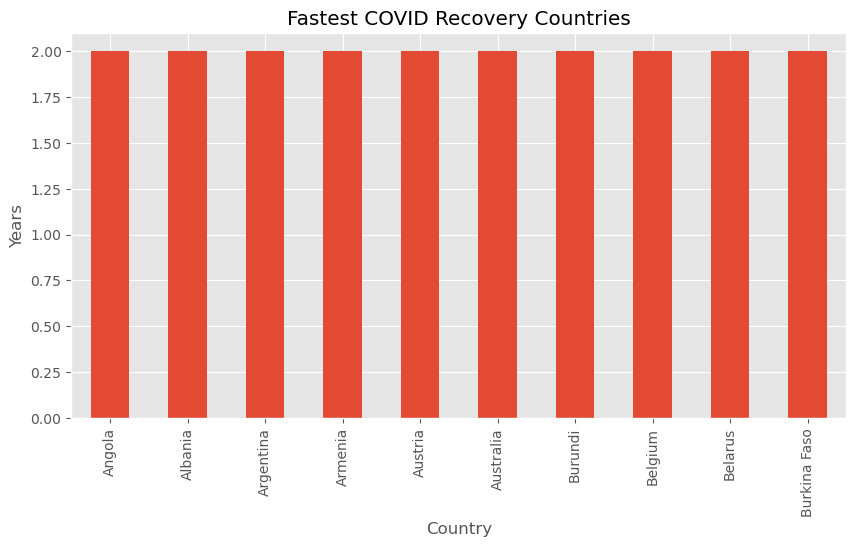

In [30]:
plt.figure(figsize=(10,5))

covid_df.sort_values("Covid_Recovery_Years").head(10).set_index("Country")[
    "Covid_Recovery_Years"
].plot(kind="bar")

plt.title("Fastest COVID Recovery Countries")
plt.ylabel("Years")

plt.show()

In [31]:
covid_df[covid_df["Country"] == "India"]

,Country,Covid_Recovery_Years
74,India,2.0
